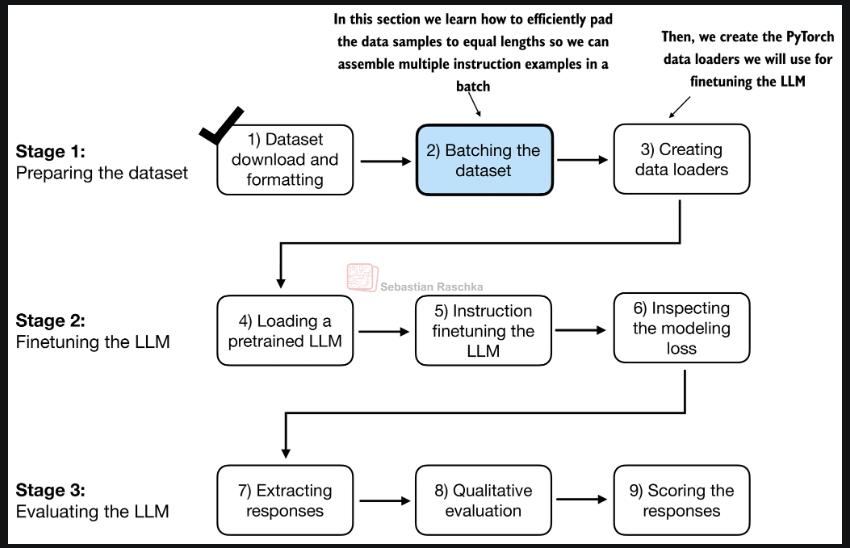

In [11]:
import os
import requests
import json

url = "https://datasets-server.huggingface.co/rows?dataset=glaiveai%2Fglaive-function-calling-v2&config=default&split=train&offset=0&length=100"

response = requests.get(url, timeout=30)
response.raise_for_status()
content = json.loads(response.content)

data = []
for row in content["rows"]:
    data.append(row['row'])

In [34]:
def format_entry(entry):
    system = entry['system'].strip().replace('SYSTEM', '###SYSTEM')

    turns = [t.strip().replace("<|endoftext|>", "").replace('USER', '###USER').replace('ASSISTANT', '###ASSISTANT') for t in entry['chat'].split('\n\n\n') if t.strip()]

    instruction = ""
    response = ""

    for turn in turns:
        if (turn.startswith('###ASSISTANT:') and ('<functioncall>' in turn or 'sorry' in turn)):
            response = turn
            break
        else:
            instruction = instruction + '\n' +  turn

    
    return system + '\n' + instruction, response

In [35]:
import tiktoken
import torch
from torch.utils.data import Dataset, DataLoader

In [78]:
class InstructionDataset(Dataset):
    allowed_max_length = 1024

    def __init__(self, data, tokenizer):
        self.data = data

        self.encoded_texts = []

        for entry in data:            
            prompt, response = format_entry(entry)                                                                                                                                           
            prompt_ids = tokenizer.encode(prompt)                                                                                                                                                         
            response_ids = tokenizer.encode(response)                                                                                                                                                     
            token_ids = prompt_ids + response_ids    

            if len(token_ids) + 1 > self.allowed_max_length:                                                                                                                                          
                continue    

            self.encoded_texts.append((token_ids, len(prompt_ids)))

    def __len__(self):
        return len(self.encoded_texts)
    
    def __getitem__(self, index):
        return self.encoded_texts[index]




In [49]:
train_portion = int(len(data) * 0.85)
val_portion = int(len(data) * 0.1)
test_portion = len(data) - train_portion - val_portion

train_data = data[:train_portion]
val_data = data[train_portion:train_portion + val_portion]
test_data = data[train_portion + val_portion:]

In [50]:
print("Training set length:", len(train_data))
print("Validation set length:", len(val_data))
print("Test set length:", len(test_data))

Training set length: 85
Validation set length: 10
Test set length: 5


In [68]:
def custom_collate_fn(                                                                                                                                                                                          
    batch,      
    pad_token_id=50256,
    ignore_index=-100,
    device="cpu"
):                                                                                                                                                                                                              
    batch_max_length = max(len(token_ids)+1 for token_ids, _ in batch)
                                                                                                                                                                                                                
    inputs_lst, targets_lst = [], []
                                                                                                                                                                                                                
    for token_ids, prompt_len in batch:
        new_item = token_ids.copy()
        new_item += [pad_token_id] # token for end of sequence                                                                                                                                                             
        padded = new_item + [pad_token_id] * (batch_max_length - len(new_item)) # rest are paddings
                                                                                                                                                                                                                
        inputs = torch.tensor(padded[:-1])                                                                                                                                                                      
        targets = torch.tensor(padded[1:])

        mask = targets == pad_token_id  # get where it is 50256 and have them True. 
                                        # Ex [1,2,50256, 50256] ->[False, False, True, True]
        
        indices = torch.nonzero(mask).squeeze() # Get their indices : [2, 3]
        
        if indices.numel() > 1:                 #Check if indices have elements more than 1. 
                                                #If it is 1 or less, ignore, as it is for eos token
            targets[indices[1:]] = ignore_index # Set -100 for all pads, except for eos token. note: eos and pads use 50256 idx                                                                                                                                                           

        targets[:prompt_len - 1] = ignore_index  # mask all prompt tokens from the targets. prompt_len - 1 because of targets = torch.tensor(padded[1:])
                                                                                                         
                
        inputs_lst.append(inputs)
        targets_lst.append(targets)                                                                                                                                                                             
                
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor                                                                                                                                                                        

In [70]:
inputs_1 = ([0, 1, 2, 3, 4], 3)
inputs_2 = ([5, 6], 1)
inputs_3 = ([7, 8, 9], 2)

batch = (
    inputs_1,
    inputs_2,
    inputs_3
)

inputs, targets = custom_collate_fn(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[ -100,  -100,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [ -100,     9, 50256,  -100,  -100]])


In [71]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Use PyTorch 2.9 or newer for stable mps results
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
else:
    device = torch.device("cpu")

print("Device:", device)

Device: mps


In [73]:
from functools import partial

customized_collate_fn = partial(
    custom_collate_fn,
    device=device,
)

In [75]:
import tiktoken
tokenizer = tiktoken.get_encoding('gpt2')

In [79]:
from torch.utils.data import DataLoader


num_workers = 0
batch_size = 8

torch.manual_seed(123)

train_dataset = InstructionDataset(train_data, tokenizer)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers
)

In [82]:
val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

In [85]:
print("Train loader:")
for inputs, targets in train_loader:
    print(inputs.shape, targets.shape)

Train loader:
torch.Size([8, 987]) torch.Size([8, 987])
torch.Size([8, 981]) torch.Size([8, 981])
torch.Size([8, 874]) torch.Size([8, 874])
torch.Size([8, 814]) torch.Size([8, 814])
torch.Size([8, 985]) torch.Size([8, 985])
torch.Size([8, 939]) torch.Size([8, 939])
torch.Size([8, 855]) torch.Size([8, 855])
torch.Size([8, 680]) torch.Size([8, 680])
torch.Size([8, 886]) torch.Size([8, 886])
